# Analysis notebook for group 10: Docker vs Podman
Here you can find the code for creating all plots and graphs for our 1st assignment.

In [105]:
%pip install pandas numpy matplotlib scipy seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

### Import files remove outliers based on IQR

In [234]:
# Remove outlier runs based on final energy consumption (IDEMPOTENT)
# Uses combined IQR bounds for both Docker and Podman for fair comparison

def calculate_combined_bounds():
    """Calculate IQR bounds from combined Docker and Podman data"""
    energy_columns = ['PP0_ENERGY (J)', 'DRAM_ENERGY (J)']
    all_energies = []
    
    # Collect energy from both platforms
    for platform in ['docker', 'podman']:
        test_dir = Path('test_results') / platform
        csvs = sorted(glob(str(test_dir / 'test_*' / '*.csv')))
        runs = [pd.read_csv(csv) for csv in csvs]
        runs = runs[5:]  # Skip warm-up
        
        for df in runs:
            available_cols = [col for col in energy_columns if col in df.columns]
            total_energy = (df[available_cols].iloc[-1] - df[available_cols].iloc[0]).sum()
            all_energies.append(total_energy)
    
    all_energies = np.array(all_energies)
    
    # Calculate combined IQR
    Q1 = np.percentile(all_energies, 25)
    Q3 = np.percentile(all_energies, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 5.0 * IQR
    upper_bound = Q3 + 5.0 * IQR
    
    return lower_bound, upper_bound

def remove_energy_outliers(platform, bounds):
    """Remove outlier runs using shared bounds (reloads from disk for idempotency)"""
    lower_bound, upper_bound = bounds
    
    # Reload runs from scratch
    test_dir = Path('test_results') / platform
    csvs = sorted(glob(str(test_dir / 'test_*' / '*.csv')))
    runs = [pd.read_csv(csv) for csv in csvs]
    runs = runs[5:]  # Skip warm-up
    
    # Calculate total energy for each run using only CPU (PP0) and DRAM
    energy_columns = ['PP0_ENERGY (J)', 'DRAM_ENERGY (J)']
    
    run_energies = []
    for df in runs:
        available_cols = [col for col in energy_columns if col in df.columns]
        total_energy = (df[available_cols].iloc[-1] - df[available_cols].iloc[0]).sum()
        run_energies.append(total_energy)
    
    run_energies = np.array(run_energies)
    
    # Identify outliers using shared bounds
    outlier_mask = (run_energies < lower_bound) | (run_energies > upper_bound)
    outlier_indices = np.where(outlier_mask)[0]
    
    # Print outlier information
    if len(outlier_indices) > 0:
        print(f'{platform} - Found {len(outlier_indices)} outlier(s):')
        for idx in outlier_indices:
            print(f'  Run {idx}: {run_energies[idx]:.2f} J')
    else:
        print(f'{platform} - No outliers detected')
    
    # Return filtered runs
    filtered_runs = [runs[i] for i in range(len(runs)) if i not in outlier_indices]
    print(f'{platform} - Kept {len(filtered_runs)} / {len(runs)} runs (after warm-up)\n')
    
    return filtered_runs

# Calculate shared bounds for both platforms
print('Calculating shared IQR bounds from combined Docker and Podman data...')
shared_bounds = calculate_combined_bounds()
print(f'Shared bounds: {shared_bounds[0]:.2f} - {shared_bounds[1]:.2f} J\n')

# Remove outliers using shared bounds
docker_runs = remove_energy_outliers('docker', shared_bounds)
podman_runs = remove_energy_outliers('podman', shared_bounds)

Calculating shared IQR bounds from combined Docker and Podman data...
Shared bounds: 9496.39 - 11606.22 J

docker - Found 2 outlier(s):
  Run 10: -251594.36 J
  Run 19: -251566.15 J
docker - Kept 28 / 30 runs (after warm-up)

podman - Found 1 outlier(s):
  Run 0: 9457.92 J
podman - Kept 29 / 30 runs (after warm-up)



### Plot CPU usage avaraged over all runs each for Docker and Podman

In [235]:
# Normalize time and average CPU usage across runs
def average_runs(runs):
    """Normalize time for each run, interpolate to common time axis, and average"""
    # Normalize time to start at 0 for each run (convert to seconds)
    normalized_runs = []
    for df in runs:
        df_norm = df.copy()
        df_norm['time'] = (df_norm['Time'] - df_norm['Time'].min()) / 1000
        normalized_runs.append(df_norm)
    
    # Create common time axis
    max_time = max(df['time'].max() for df in normalized_runs)
    time_axis = np.linspace(0, max_time, 1000)
    
    # Get CPU columns
    cpu_cols = [col for col in runs[0].columns if col.startswith('CPU_USAGE_')]
    
    # Interpolate and average
    all_cpu_data = []
    for df_norm in normalized_runs:
        cpu_mean = df_norm[cpu_cols].mean(axis=1)  # Average across CPUs
        cpu_interp = np.interp(time_axis, df_norm['time'], cpu_mean)
        all_cpu_data.append(cpu_interp)
    
    all_cpu_data = np.array(all_cpu_data)
    mean = all_cpu_data.mean(axis=0)
    std = all_cpu_data.std(axis=0)
    
    return time_axis, mean, std

docker_time, docker_mean, docker_std = average_runs(docker_runs)
podman_time, podman_mean, podman_std = average_runs(podman_runs)

print('Averaged runs ready')

Averaged runs ready


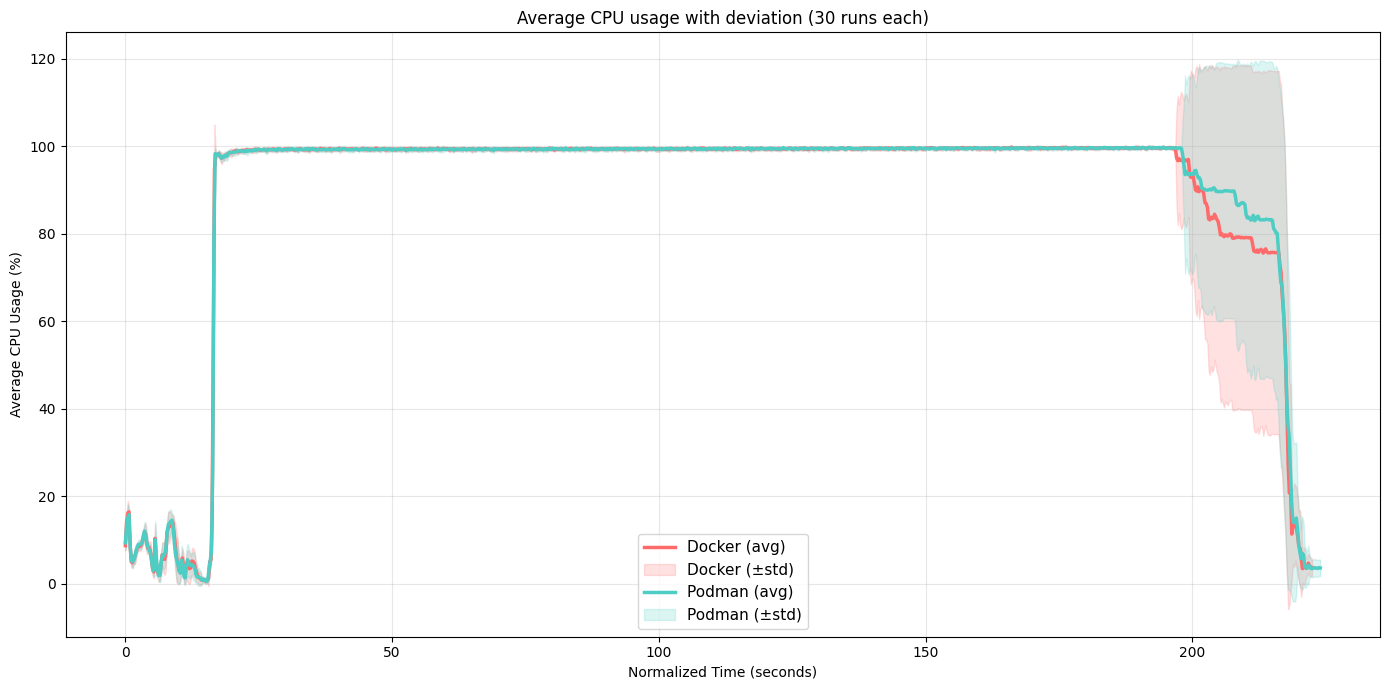

In [253]:
# Plot Docker vs Podman - averaged CPU usage with deviation
plt.figure(figsize=(14, 7))

# Docker
plt.plot(docker_time, docker_mean, label='Docker (avg)', linewidth=2.5, color='#FF6B6B')
plt.fill_between(docker_time,
                  docker_mean - docker_std,
                  docker_mean + docker_std,
                  alpha=0.2, color='#FF6B6B', label='Docker (±std)')

# Podman
plt.plot(podman_time, podman_mean, label='Podman (avg)', linewidth=2.5, color='#4ECDC4')
plt.fill_between(podman_time,
                  podman_mean - podman_std,
                  podman_mean + podman_std,
                  alpha=0.2, color='#4ECDC4', label='Podman (±std)')

plt.xlabel('Normalized Time (seconds)')
plt.ylabel('Average CPU Usage (%)')
plt.title('Average CPU usage with deviation (30 runs each)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot cumulative energy usage for Podman and Docker

In [241]:
# Calculate cumulative energy for each run
def calculate_energy(runs):
    """Calculate cumulative energy for each run using energy deltas"""
    energy_columns = ['PP0_ENERGY (J)', 'DRAM_ENERGY (J)'] # package and pp1 not included because we dont use gpu
    
    energy_runs = []
    for df in runs:
        df_energy = df.copy()
        # Normalize time to start at 0 (in seconds)
        df_energy['time'] = (df_energy['Time'] - df_energy['Time'].min()) / 1000
        
        # Calculate total energy by summing available energy columns
        available_cols = [col for col in energy_columns if col in df_energy.columns]
        
        if available_cols:
            # Sum energy deltas (difference from first measurement)
            df_energy['cumulative_energy'] = df_energy[available_cols].sum(axis=1) - df_energy[available_cols].iloc[0].sum()
        else:
            raise ValueError(f'No energy columns found. Available: {df_energy.columns.tolist()}')
        
        energy_runs.append(df_energy)
    
    return energy_runs

docker_energy_runs = calculate_energy(docker_runs)
podman_energy_runs = calculate_energy(podman_runs)

print('Energy calculated for all runs')

Energy calculated for all runs


In [243]:
# Normalize and average energy across runs
def average_energy_runs(runs):
    """Average cumulative energy across runs"""
    # Create common time axis
    max_time = max(df['time'].max() for df in runs)
    time_axis = np.linspace(0, max_time, 1000)
    
    # Interpolate energy for each run
    all_energy_data = []
    for df in runs:
        energy_interp = np.interp(time_axis, df['time'], df['cumulative_energy'])
        all_energy_data.append(energy_interp)
    
    all_energy_data = np.array(all_energy_data)
    mean = all_energy_data.mean(axis=0)
    std = all_energy_data.std(axis=0)
    
    return time_axis, mean, std

docker_energy_time, docker_energy_mean, docker_energy_std = average_energy_runs(docker_energy_runs)
podman_energy_time, podman_energy_mean, podman_energy_std = average_energy_runs(podman_energy_runs)

print('Energy averaged across runs')

Energy averaged across runs


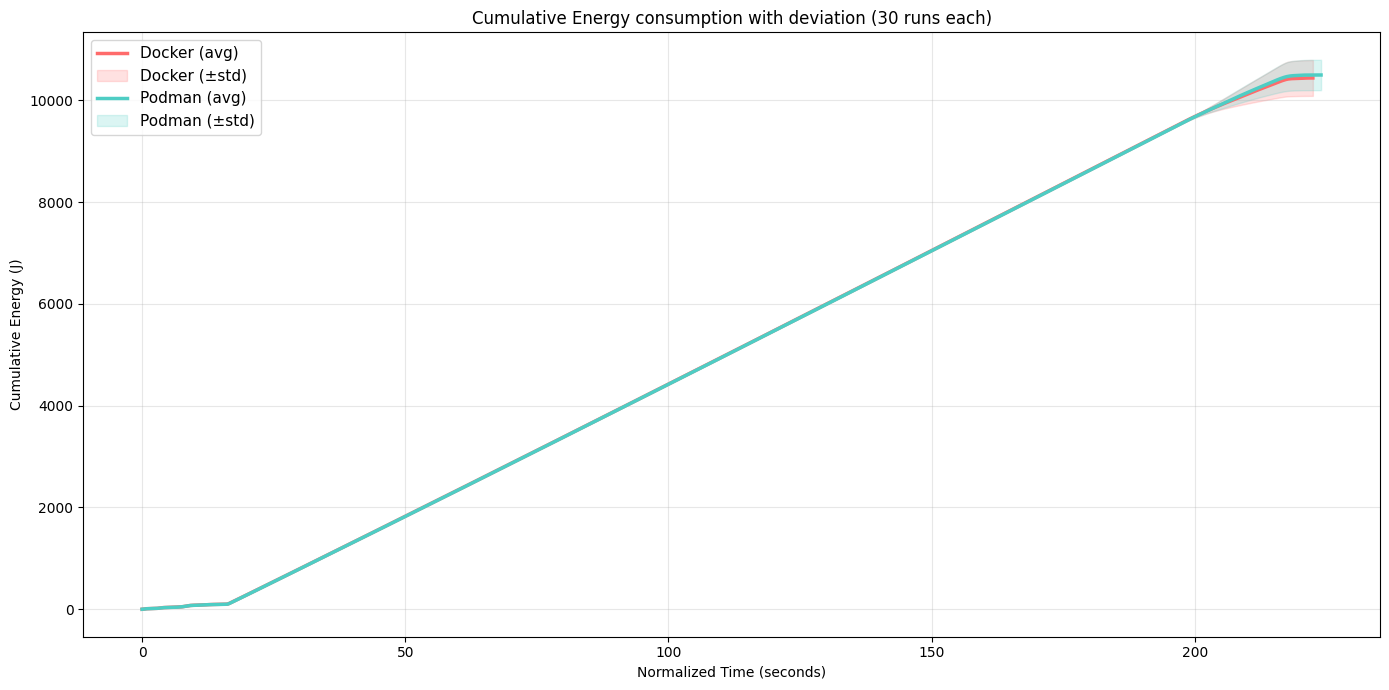

In [254]:
# Plot Docker vs Podman - averaged energy consumption with deviation
plt.figure(figsize=(14, 7))

# Docker
plt.plot(docker_energy_time, docker_energy_mean, label='Docker (avg)', linewidth=2.5, color='#FF6B6B')
plt.fill_between(docker_energy_time,
                  docker_energy_mean - docker_energy_std,
                  docker_energy_mean + docker_energy_std,
                  alpha=0.2, color='#FF6B6B', label='Docker (±std)')

# Podman
plt.plot(podman_energy_time, podman_energy_mean, label='Podman (avg)', linewidth=2.5, color='#4ECDC4')
plt.fill_between(podman_energy_time,
                  podman_energy_mean - podman_energy_std,
                  podman_energy_mean + podman_energy_std,
                  alpha=0.2, color='#4ECDC4', label='Podman (±std)')

plt.xlabel('Normalized Time (seconds)')
plt.ylabel('Cumulative Energy (J)')
plt.title('Cumulative Energy consumption with deviation (30 runs each)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Violin plots of cumulative energy usage

/var/folders/vb/__pnj35956n9w3p42gs6dxmm0000gn/T/ipykernel_14101/3474977653.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_data, x='platform', y='total_energy', palette=['#FF6B6B', '#4ECDC4'])


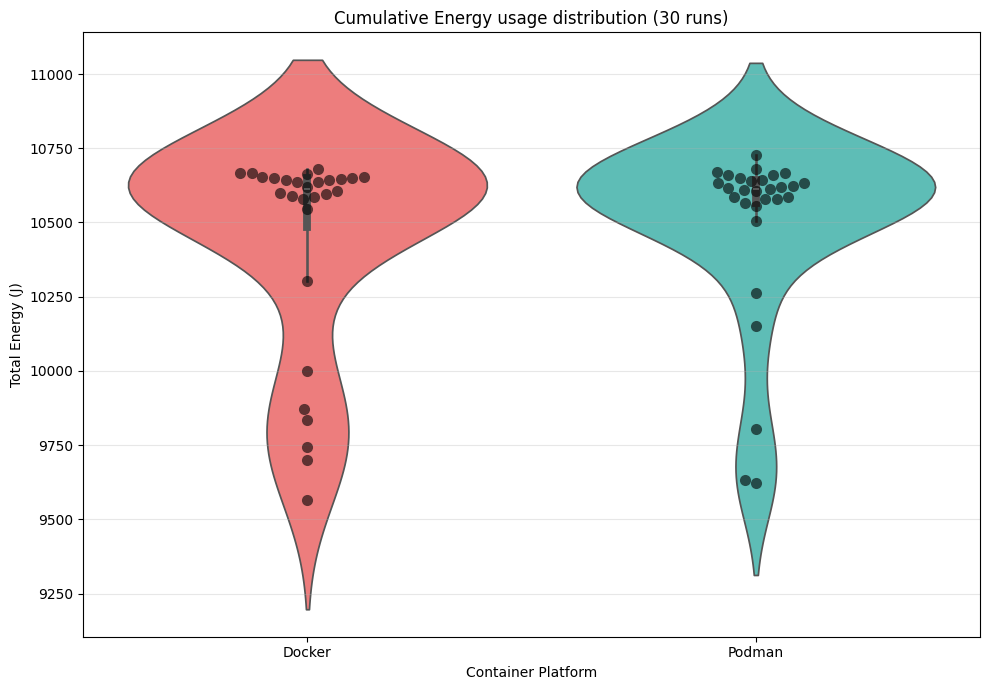

Docker - Mean: 10437.10 J, Std: 352.16 J
Podman - Mean: 10495.65 J, Std: 298.41 J


In [255]:
import seaborn as sns

# Extract total energy for each run
docker_energies = [df['cumulative_energy'].iloc[-1] for df in docker_energy_runs]
podman_energies = [df['cumulative_energy'].iloc[-1] for df in podman_energy_runs]

# Create dataframe for violin plot
violin_data = pd.DataFrame({
    'platform': ['Docker'] * len(docker_energies) + ['Podman'] * len(podman_energies),
    'total_energy': docker_energies + podman_energies
})

# Create violin plot
plt.figure(figsize=(10, 7))
sns.violinplot(data=violin_data, x='platform', y='total_energy', palette=['#FF6B6B', '#4ECDC4'])
sns.swarmplot(data=violin_data, x='platform', y='total_energy', color='black', alpha=0.6, size=8)

plt.ylabel('Total Energy (J)')
plt.xlabel('Container Platform')
plt.title('Cumulative Energy usage distribution (30 runs)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Docker - Mean: {np.mean(docker_energies):.2f} J, Std: {np.std(docker_energies):.2f} J')
print(f'Podman - Mean: {np.mean(podman_energies):.2f} J, Std: {np.std(podman_energies):.2f} J')

### Boxplot for total cumulative energy usage

/var/folders/vb/__pnj35956n9w3p42gs6dxmm0000gn/T/ipykernel_14101/301755015.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=violin_data, x='platform', y='total_energy', palette=['#FF6B6B', '#4ECDC4'])


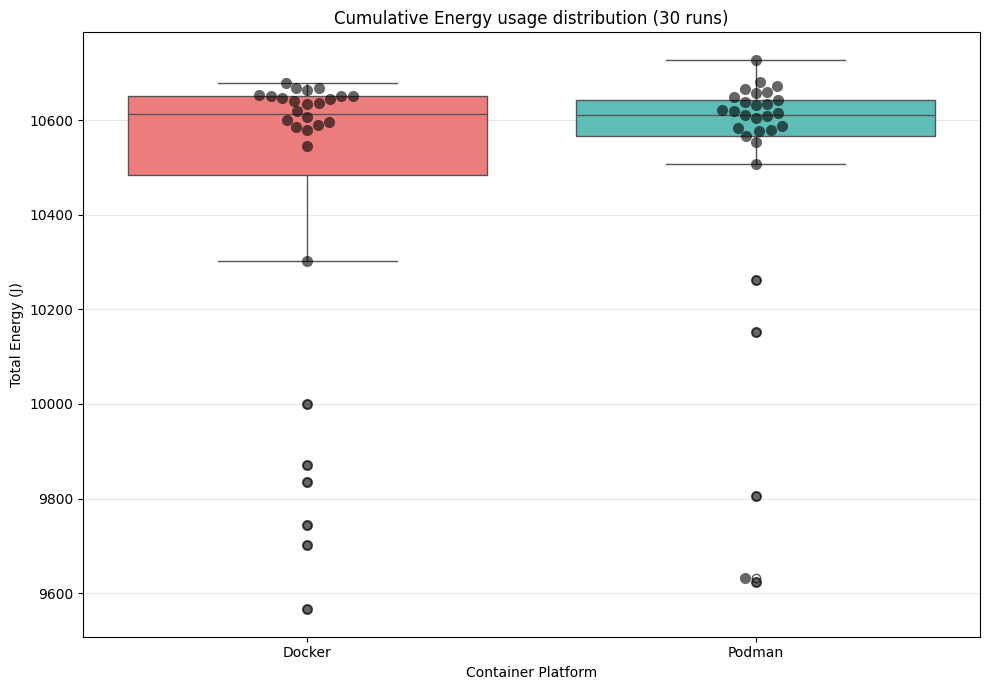

In [256]:
# Boxplot for energy distribution
plt.figure(figsize=(10, 7))
sns.boxplot(data=violin_data, x='platform', y='total_energy', palette=['#FF6B6B', '#4ECDC4'])
sns.swarmplot(data=violin_data, x='platform', y='total_energy', color='black', alpha=0.6, size=8)

plt.ylabel('Total Energy (J)')
plt.xlabel('Container Platform')
plt.title('Cumulative Energy usage distribution (30 runs)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Total view of energy used in experiment

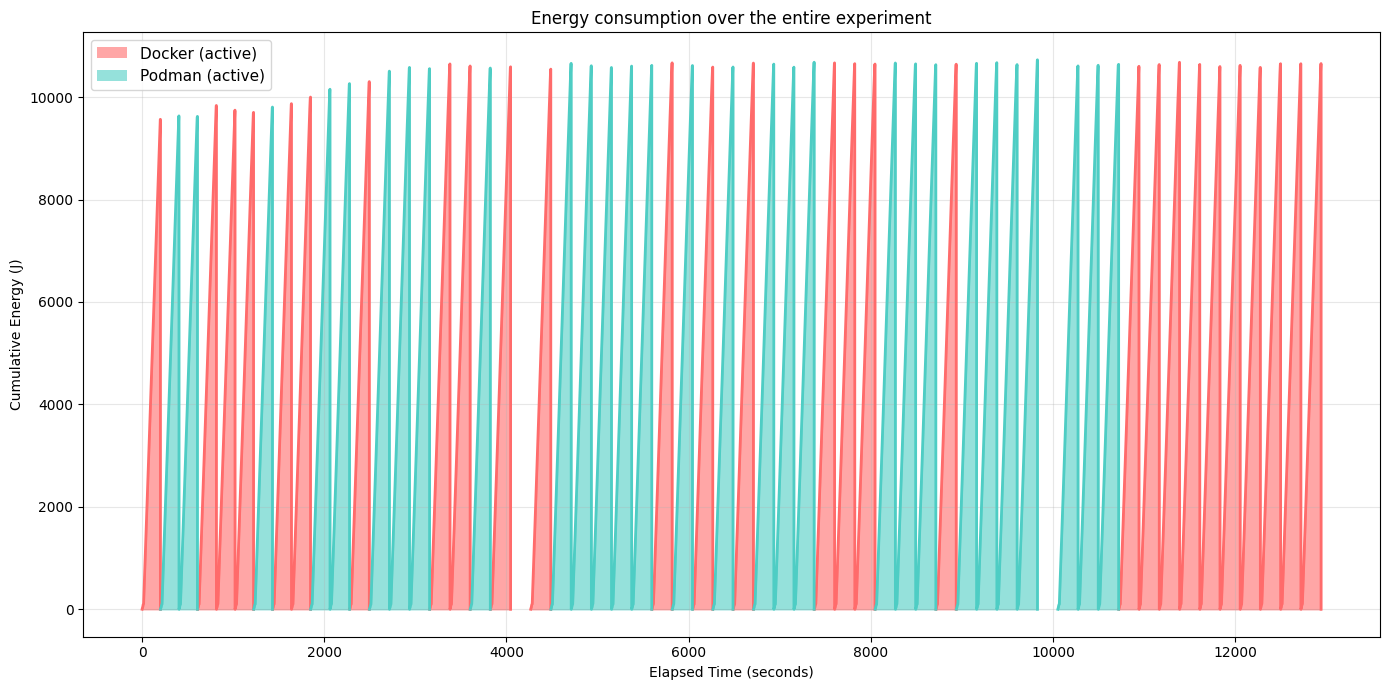

In [257]:
# Energy plot which shows overview of all experiments
# Combine all runs with platform labels
all_samples = []

for df in docker_energy_runs:
    df_copy = df.copy()
    df_copy['platform'] = 'Docker'
    all_samples.append(df_copy)

for df in podman_energy_runs:
    df_copy = df.copy()
    df_copy['platform'] = 'Podman'
    all_samples.append(df_copy)

df_all = pd.concat(all_samples, ignore_index=True)

# Normalize time across entire experiment
min_time = df_all['Time'].min()
max_time = df_all['Time'].max()
df_all['elapsed_time'] = (df_all['Time'] - min_time) / 1000

# Separate by platform
docker_data = df_all[df_all['platform'] == 'Docker'].sort_values('elapsed_time').reset_index(drop=True)
podman_data = df_all[df_all['platform'] == 'Podman'].sort_values('elapsed_time').reset_index(drop=True)

# Create plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot Docker segments
docker_segments = []
current_segment = []
for idx, row in docker_data.iterrows():
    current_segment.append(row)
    # Check if this is the last row or if there's a gap to the next
    if idx == len(docker_data) - 1 or (docker_data.loc[idx + 1, 'elapsed_time'] - row['elapsed_time']) > 5:
        docker_segments.append(pd.DataFrame(current_segment))
        current_segment = []

# Plot each Docker segment with vertical drop
for segment in docker_segments:
    segment_with_drop = pd.concat([segment, pd.DataFrame([{'elapsed_time': segment.iloc[-1]['elapsed_time'], 'cumulative_energy': 0}])], ignore_index=True)
    ax.fill_between(segment_with_drop['elapsed_time'], 0, segment_with_drop['cumulative_energy'],
                    color='#FF6B6B', alpha=0.6)
    ax.plot(segment_with_drop['elapsed_time'], segment_with_drop['cumulative_energy'],
           linewidth=2, color='#FF6B6B')

# Plot Podman segments
podman_segments = []
current_segment = []
for idx, row in podman_data.iterrows():
    current_segment.append(row)
    if idx == len(podman_data) - 1 or (podman_data.loc[idx + 1, 'elapsed_time'] - row['elapsed_time']) > 5:
        podman_segments.append(pd.DataFrame(current_segment))
        current_segment = []

# Plot each Podman segment with vertical drop
for segment in podman_segments:
    segment_with_drop = pd.concat([segment, pd.DataFrame([{'elapsed_time': segment.iloc[-1]['elapsed_time'], 'cumulative_energy': 0}])], ignore_index=True)
    ax.fill_between(segment_with_drop['elapsed_time'], 0, segment_with_drop['cumulative_energy'],
                    color='#4ECDC4', alpha=0.6)
    ax.plot(segment_with_drop['elapsed_time'], segment_with_drop['cumulative_energy'],
           linewidth=2, color='#4ECDC4')

# Manual legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', alpha=0.6, label='Docker (active)'),
                  Patch(facecolor='#4ECDC4', alpha=0.6, label='Podman (active)')]
ax.legend(handles=legend_elements, loc='best', fontsize=11)

ax.set_xlabel('Elapsed Time (seconds)')
ax.set_ylabel('Cumulative Energy (J)')
ax.set_title('Energy consumption over the entire experiment')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [221]:
from scipy.stats import shapiro

# Extract final energy values for each run
docker_energies = [df['cumulative_energy'].iloc[-1] for df in docker_energy_runs]
podman_energies = [df['cumulative_energy'].iloc[-1] for df in podman_energy_runs]

# Perform Shapiro-Wilks test
docker_stat, docker_p = shapiro(docker_energies)
podman_stat, podman_p = shapiro(podman_energies)

# Display results
print('Shapiro-Wilks Normality Test')
print('=' * 50)
print(f'Docker:')
print(f'  Test Statistic: {docker_stat:.6f}')
print(f'  P-value: {docker_p:.6f}')
print(f'  Normal Distribution: {"Yes (p > 0.05)" if docker_p > 0.05 else "No (p < 0.05)"}')
print()
print(f'Podman:')
print(f'  Test Statistic: {podman_stat:.6f}')
print(f'  P-value: {podman_p:.6f}')
print(f'  Normal Distribution: {"Yes (p > 0.05)" if podman_p > 0.05 else "No (p < 0.05)"}')

Shapiro-Wilks Normality Test
Docker:
  Test Statistic: 0.656136
  P-value: 0.000001
  Normal Distribution: No (p < 0.05)

Podman:
  Test Statistic: 0.604075
  P-value: 0.000000
  Normal Distribution: No (p < 0.05)


### Energy plot on each time point *(non-cumulative)*

In [258]:
# Calculate instantaneous power from energy deltas
def average_power_over_time(runs):
    """Calculate instantaneous power from energy column deltas"""
    energy_columns = ['PP0_ENERGY (J)', 'DRAM_ENERGY (J)'] # package and pp1 not included because we dont use gpu
    
    # Create common time axis
    max_time = max(df['time'].max() for df in runs)
    time_axis = np.linspace(0, max_time, 1000)
    
    all_power_data = []
    
    for df in runs:
        # Get available energy columns
        available_cols = [col for col in energy_columns if col in df.columns]
        
        # Sum energy from all columns
        total_energy = df[available_cols].sum(axis=1)
        
        # Calculate energy delta (energy used in each time span)
        energy_delta = np.diff(total_energy, prepend=total_energy.iloc[0])
        
        # Calculate time delta
        time_delta = np.diff(df['time'], prepend=0)
        
        # Calculate instantaneous power (energy / time)
        instantaneous_power = np.where(time_delta > 0.001, energy_delta / time_delta, 0)
        
        # Interpolate to common time axis
        power_interp = np.interp(time_axis, df['time'], instantaneous_power)
        all_power_data.append(power_interp)
    
    all_power_data = np.array(all_power_data)
    mean = all_power_data.mean(axis=0)
    std = all_power_data.std(axis=0)
    
    return time_axis, mean, std

docker_power_time, docker_power_mean, docker_power_std = average_power_over_time(docker_energy_runs)
podman_power_time, podman_power_mean, podman_power_std = average_power_over_time(podman_energy_runs)

print('Instantaneous power calculated from energy deltas')

Instantaneous power calculated from energy deltas


/var/folders/vb/__pnj35956n9w3p42gs6dxmm0000gn/T/ipykernel_14101/1451033122.py:26: RuntimeWarning: divide by zero encountered in divide
  instantaneous_power = np.where(time_delta > 0.001, energy_delta / time_delta, 0)
/var/folders/vb/__pnj35956n9w3p42gs6dxmm0000gn/T/ipykernel_14101/1451033122.py:26: RuntimeWarning: invalid value encountered in divide
  instantaneous_power = np.where(time_delta > 0.001, energy_delta / time_delta, 0)
/var/folders/vb/__pnj35956n9w3p42gs6dxmm0000gn/T/ipykernel_14101/1451033122.py:26: RuntimeWarning: divide by zero encountered in divide
  instantaneous_power = np.where(time_delta > 0.001, energy_delta / time_delta, 0)
/var/folders/vb/__pnj35956n9w3p42gs6dxmm0000gn/T/ipykernel_14101/1451033122.py:26: RuntimeWarning: invalid value encountered in divide
  instantaneous_power = np.where(time_delta > 0.001, energy_delta / time_delta, 0)
/var/folders/vb/__pnj35956n9w3p42gs6dxmm0000gn/T/ipykernel_14101/1451033122.py:26: RuntimeWarning: divide by zero encountered 

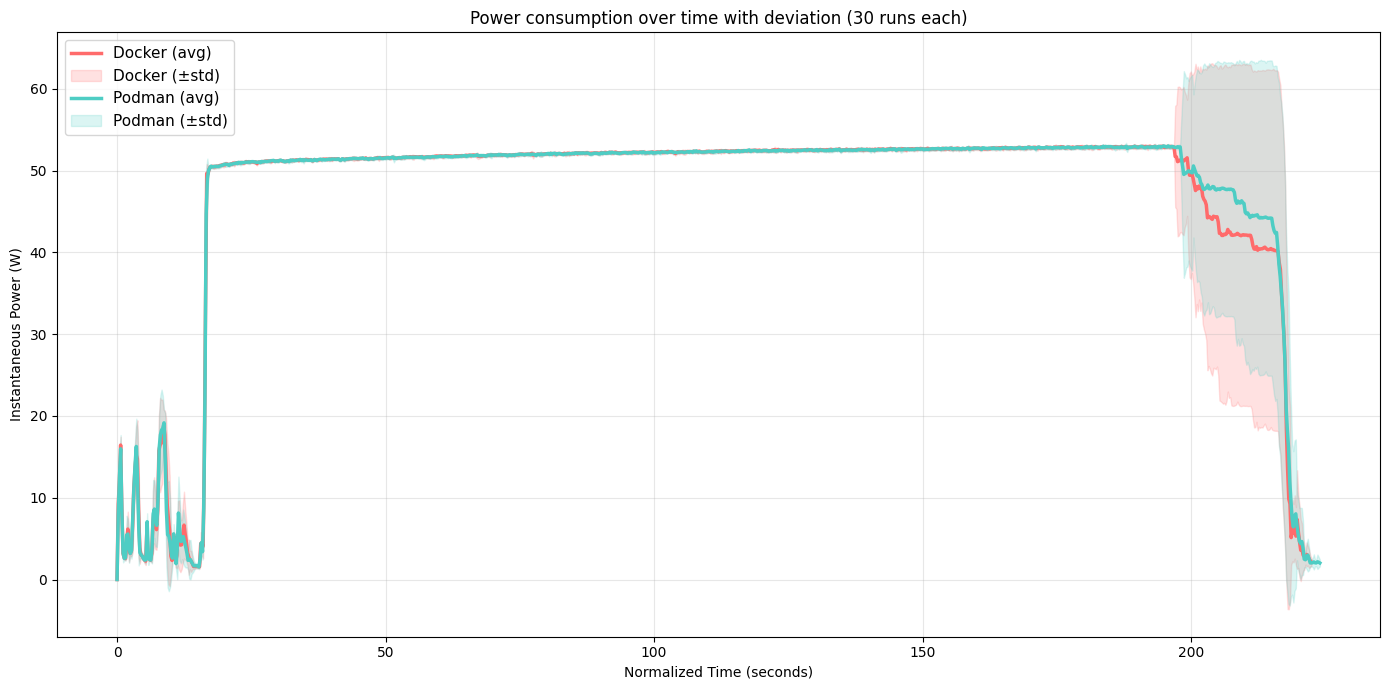

In [259]:
# Plot instantaneous power over normalized time
plt.figure(figsize=(14, 7))

# Docker
plt.plot(docker_power_time, docker_power_mean, label='Docker (avg)', linewidth=2.5, color='#FF6B6B')
plt.fill_between(docker_power_time,
                  docker_power_mean - docker_power_std,
                  docker_power_mean + docker_power_std,
                  alpha=0.2, color='#FF6B6B', label='Docker (±std)')

# Podman
plt.plot(podman_power_time, podman_power_mean, label='Podman (avg)', linewidth=2.5, color='#4ECDC4')
plt.fill_between(podman_power_time,
                  podman_power_mean - podman_power_std,
                  podman_power_mean + podman_power_std,
                  alpha=0.2, color='#4ECDC4', label='Podman (±std)')

plt.xlabel('Normalized Time (seconds)')
plt.ylabel('Instantaneous Power (W)')
plt.title('Power consumption over time with deviation (30 runs each)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()